# Water Quality Data Preparation

## Overview
This notebook retrieves and prepares in-situ water quality data for the Upper Florida Keys estuary over 2015–2024 from the [Water Quality Portal (WQP)](https://www.waterqualitydata.us/) API.

1. Data Download
2. Filter Relevant Columns and Status
3. Extract Units and Pivot Parameters
4. Merge Station Coordinates
5. Build GeoDataFrame and Save

**Data source:** Water Quality Portal (WQP) — STORET/EPA network \
**Study area:** Upper Florida Keys, FL — bounding box `-80.65, 24.85, -80.20, 25.35` \
**Parameters:** Turbidity (NTU), Salinity (PSS), Temperature (°C), Secchi Depth (m), Chlorophyll-a (µg/L)

---

## Imports & Pip Install

In [12]:
import requests
import pandas as pd
from io import StringIO
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

## Data Download

Query the WQP API for relative parameter across ocean / estuary sites within the bounding box: "-80.65, 24.85, -80.20, 25.35." 

**Parameters:** Turbidity, Salinity, Temperature, Secchi Disk Depth, Chlorophyll-a

In [ ]:
# Querey information data from the WQP
url = "https://www.waterqualitydata.us/data/Result/search"

# Define relevant parameters
params = {
    "bBox": "-80.65,24.85,-80.20,25.35",
    "siteType": "Estuary",
    "startDateLo": "01-01-2015",
    "startDateHi": "12-31-2024",
    "sampleMedia": "Water",
    "characteristicName": [
        "Turbidity",
        "Salinity",
        "Temperature, water",
        "Chlorophyll a",
        "Depth, Secchi disk depth"
    ],
    "mimeType": "csv"
}
# Display download progress
print("Downloading Upper Keys water quality results...")
response = requests.get(url, params=params)
print(f"Status: {response.status_code}")

if response.status_code == 200:
    df_wq = pd.read_csv(StringIO(response.text))
    print(f"Total rows: {df_wq.shape[0]}")
    print(f"Columns: {df_wq.columns.tolist()}")
    print(df_wq.head())
    
    # Save
    df_wq.to_csv("upper_keys_results.csv", index=False)
    print("Saved as upper_keys_results.csv")
else:
    print(f"Error: {response.text[:500]}")

Status: 200
Total rows: 8056
Columns: ['OrganizationIdentifier', 'OrganizationFormalName', 'ActivityIdentifier', 'ActivityTypeCode', 'ActivityMediaName', 'ActivityMediaSubdivisionName', 'ActivityStartDate', 'ActivityStartTime/Time', 'ActivityStartTime/TimeZoneCode', 'ActivityEndDate', 'ActivityEndTime/Time', 'ActivityEndTime/TimeZoneCode', 'ActivityDepthHeightMeasure/MeasureValue', 'ActivityDepthHeightMeasure/MeasureUnitCode', 'ActivityDepthAltitudeReferencePointText', 'ActivityTopDepthHeightMeasure/MeasureValue', 'ActivityTopDepthHeightMeasure/MeasureUnitCode', 'ActivityBottomDepthHeightMeasure/MeasureValue', 'ActivityBottomDepthHeightMeasure/MeasureUnitCode', 'ProjectIdentifier', 'ActivityConductingOrganizationText', 'MonitoringLocationIdentifier', 'ActivityCommentText', 'SampleAquifer', 'HydrologicCondition', 'HydrologicEvent', 'SampleCollectionMethod/MethodIdentifier', 'SampleCollectionMethod/MethodIdentifierContext', 'SampleCollectionMethod/MethodName', 'SampleCollectionEquipmentN

In [14]:
display(df_wq.head())

,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,...,ResultAnalyticalMethod/MethodName,MethodDescriptionText,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,PreparationStartDate,ProviderName
0,21FLWQA_WQX,FDEP Watershed Assessment Section (WAS),21FLWQA_WQX-G5AA0008-11/23/20,Sample-Routine,Water,Surface Water,2020-11-23,13:16:00,EST,2020-11-23,...,Turbidity by Nephelometry,https://www.nemi.gov/methods/method_summary/5217/,E31780,2020-11-24,NaN,Practical Quantitation Limit,0.13,NTU,NaN,STORET
1,21FLDADE_WQX,Dade Environmental Resource Management (Florida),21FLDADE_WQX-BB48-0720S,Field Msr/Obs,Water,Surface Water,2020-07-22,09:19:00,EDT,NaN,...,FDEP FT1300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
2,21FLSFWM_WQX,South Florida Water Management District,21FLSFWM_WQX-P118758-7F,Field Msr/Obs,Water,Surface Water,2020-11-12,11:36:00,EDT,NaN,...,SFWMD FSQM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
3,21FLDADE_WQX,Dade Environmental Resource Management (Florida),21FLDADE_WQX-BB47-0120YB,Field Msr/Obs,Water,Surface Water,2020-01-08,09:07:00,EDT,NaN,...,FDEP FT1400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
4,21FLSFWM_WQX,South Florida Water Management District,21FLSFWM_WQX-P111062-6F,Field Msr/Obs,Water,Surface Water,2020-08-17,10:19:00,EDT,NaN,...,SFWMD FSQM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET


## Processing Pipeline
Records filtered to accepted quality status only: `Accepted`, `Final`, `Validated`, `Historical`. Result values coerced to numeric — non-numeric entries (e.g. `"*"`, `"<0.1"`) set to NaN. Parameters pivoted into columns with units extracted from the most commonly reported unit code per characteristic. Daily means computed per station where multiple readings exist on the same date.

### Pivot Table

Creates a new data table that pivots the relative parameters into columns. Index by datetime. 

In [15]:
# Extract units per characteristic
units = (
    df_wq.groupby("CharacteristicName")["ResultMeasure/MeasureUnitCode"]
    .agg(lambda x: x.dropna().mode()[0] if x.dropna().any() else "")
    .to_dict()
)
print("Units found:", units)

# Build rename map with units
rename_map = {
    "Temperature, water":       f"Temperature ({units.get('Temperature, water', '°C')})",
    "Depth, Secchi disk depth": f"Secchi Depth ({units.get('Depth, Secchi disk depth', 'm')})",
    "Chlorophyll a":            f"Chlorophyll_a ({units.get('Chlorophyll a', 'µg/L')})",
    "Turbidity":                f"Turbidity ({units.get('Turbidity', 'NTU')})",
    "Salinity":                 f"Salinity ({units.get('Salinity', 'ppt')})",
}

# Pivot parameters into columns
df_wq["ResultMeasureValue"] = pd.to_numeric(df_wq["ResultMeasureValue"], errors="coerce")

df_pivot = df_wq.groupby(
    ["ActivityStartDate", "MonitoringLocationIdentifier", "CharacteristicName"]
)["ResultMeasureValue"].mean().unstack("CharacteristicName").reset_index()

df_pivot.columns.name = None

# Apply rename with units baked in
df_pivot = df_pivot.rename(columns=rename_map)

# Set clean datetime index
df_pivot["ActivityStartDate"] = pd.to_datetime(df_pivot["ActivityStartDate"])
df_pivot = df_pivot.set_index("ActivityStartDate").sort_index()

print(f"\nPivoted shape: {df_pivot.shape}")
print(f"Columns: {df_pivot.columns.tolist()}")
print(df_pivot.head())

# Save
df_pivot.to_csv("upper_keys_pivot.csv")
print("Saved as upper_keys_pivot.csv")
display(df_pivot.head())

Units found: {'Depth, Secchi disk depth': 'm', 'Salinity': 'PSS', 'Temperature, water': 'deg C', 'Turbidity': 'NTU'}

Pivoted shape: (1749, 5)
Columns: ['MonitoringLocationIdentifier', 'Secchi Depth (m)', 'Salinity (PSS)', 'Temperature (deg C)', 'Turbidity (NTU)']
                  MonitoringLocationIdentifier  Secchi Depth (m)  \
ActivityStartDate                                                  
2015-01-07                   21FLDADE_WQX-BB47               NaN   
2015-01-07                   21FLDADE_WQX-BB50               NaN   
2015-01-07                   21FLDADE_WQX-BB51               NaN   
2015-02-03                   21FLSFWM_WQX-6598               2.5   
2015-02-03                   21FLSFWM_WQX-6599               1.6   

                   Salinity (PSS)  Temperature (deg C)  Turbidity (NTU)  
ActivityStartDate                                                        
2015-01-07              33.746667            25.330000              0.5  
2015-01-07              30.970000   

,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU)
ActivityStartDate,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2


### Check total parameter count

In [16]:
# Check all parameters and their counts
print("Parameters in dataset:")
print(df_wq["CharacteristicName"].value_counts())

print(f"\nTotal unique parameters: {df_wq['CharacteristicName'].nunique()}")

Parameters in dataset:
CharacteristicName
Salinity                    2696
Temperature, water          2693
Turbidity                   1574
Depth, Secchi disk depth    1093
Name: count, dtype: int64

Total unique parameters: 4


## Build GeoDataFrame 

Pulls station metadata to match Latitude and Longitude coordinates to stations, and merges those coordinates into the pivot table. With Latitude and Longitude coordinates the water quality data can be paired to a shapefile of relevant study area. 

In [17]:
# Download station metadata (coordinates)
station_url = "https://www.waterqualitydata.us/data/Station/search"
station_params = {
    "bBox": "-80.65,24.85,-80.20,25.35",
    "siteType": "Estuary",
    "mimeType": "csv"
}
stations = pd.read_csv(
    StringIO(requests.get(station_url, params=station_params).text)
)

print(f"Stations loaded: {stations.shape[0]}")

# Merge coordinates into df_pivot
df_pivot_geo = df_pivot.reset_index().merge(
    stations[[
        "MonitoringLocationIdentifier",
        "LatitudeMeasure",
        "LongitudeMeasure"
    ]].drop_duplicates("MonitoringLocationIdentifier"),
    on="MonitoringLocationIdentifier",
    how="left"
).rename(columns={
    "LatitudeMeasure": "Latitude",
    "LongitudeMeasure": "Longitude"
})

missing = df_pivot_geo["Latitude"].isna().sum()
print(f"Rows missing coordinates: {missing}")


#Build GeoDataFrame
df_pivot_geo = df_pivot_geo.dropna(subset=["Latitude", "Longitude"])

geometry = [Point(xy) for xy in zip(df_pivot_geo["Longitude"], df_pivot_geo["Latitude"])]
wq_gdf = gpd.GeoDataFrame(df_pivot_geo, geometry=geometry)

# WGS84 since coordinates come from the API as decimal degrees
wq_gdf = wq_gdf.set_crs("EPSG:4326")

# Reproject to match shapefile
reef_shape = gpd.read_file("UpperKeys_FL.shp")
print(f"Shapefile CRS: {reef_shape.crs}")
wq_gdf = wq_gdf.to_crs(reef_shape.crs)

# Restore date index
wq_gdf = wq_gdf.set_index("ActivityStartDate").sort_index()
wq_gdf.index.name = "Date"

print(f"\nFinal GeoDataFrame shape: {wq_gdf.shape}")
display(wq_gdf.head())

Stations loaded: 2102
Rows missing coordinates: 0
Shapefile CRS: PROJCS["NAD_1983_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",24],PARAMETER["longitude_of_center",-84],PARAMETER["standard_parallel_1",24],PARAMETER["standard_parallel_2",31.5],PARAMETER["false_easting",400000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Final GeoDataFrame shape: (1749, 8)


,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU),Latitude,Longitude,geometry
Date,,,,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5,25.336794,-80.320077,POINT (769962.142 153691.31)
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8,25.229898,-80.376777,POINT (764611.659 141671.903)
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4,25.251496,-80.414079,POINT (760789.398 143956.507)
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8,25.174050,-80.423081,POINT (760133.028 135344.954)
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2,25.206681,-80.440400,POINT (758285.307 138911.686)


### Monitoring stations paired with shapefile

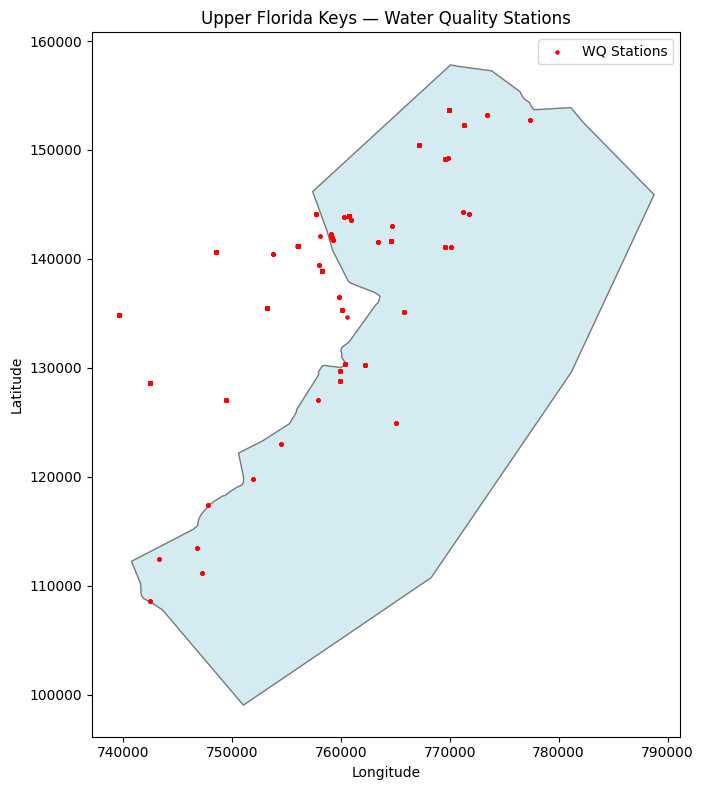

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

reef_shape.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)
wq_gdf.to_crs(reef_shape.crs).plot(ax=ax, color='red', markersize=5, label='WQ Stations')

plt.title("Upper Florida Keys — Water Quality Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

## Final Data Quality Summary

In [22]:

print("=== Data Quality Summary ===\n")
print(f"Date range:       {df_pivot.index.min().date()} to {df_pivot.index.max().date()}")
print(f"Total rows:       {len(df_pivot)}")
print(f"Unique stations:  {df_pivot['MonitoringLocationIdentifier'].nunique()}")
print(f"\nParameter coverage (non-null counts):")

param_cols = [col for col in wq_gdf.columns if any(p in col for p in 
              ["Temperature", "Salinity", "Turbidity", "Secchi", "Chlorophyll"])]

for col in param_cols:
    pct = df_pivot[col].notna().sum() / len(df_pivot) * 100
    print(f"  {col:<30} {df_pivot[col].notna().sum():>4} rows ({pct:.0%})")

print(f"\nStatus values retained: Accepted, Final, Validated, Historical")
print(f"Rows removed by status filter: {len(df_wq) - len(df_pivot)}")

=== Data Quality Summary ===

Date range:       2015-01-07 to 2024-12-11
Total rows:       1749
Unique stations:  56

Parameter coverage (non-null counts):
  Secchi Depth (m)               1082 rows (6186%)
  Salinity (PSS)                 1581 rows (9039%)
  Temperature (deg C)            1603 rows (9165%)
  Turbidity (NTU)                1567 rows (8959%)

Status values retained: Accepted, Final, Validated, Historical
Rows removed by status filter: 6307


### Save GeoDataFrame and Pivot Table for later use

In [23]:
wq_gdf.to_parquet("water_quality.parquet", index=True)
df_pivot.to_csv("upper_keys_pivot.csv", index=True)

## Summary

This notebook downloads and prepares in-situ water quality data for the 
Upper Florida Keys estuary (2015–2024) from the Water Quality Portal API.

**Outputs:**
- `upper_keys_results.csv` — raw WQP download (8,056 rows, 63 columns)
- `water_quality.parquet` — cleaned GeoDataFrame indexed by date (1,749 rows, 8 [pivoted] columns)

**Dataset overview:**
- Parameters: Turbidity (NTU), Salinity (PSS), Temperature (°C), 
  Secchi Depth (m), Chlorophyll-a (µg/L)
- Raw download: 8,056 rows × 63 columns
- Final shape: 1,749 rows × 8 columns
- Stations: 56 monitoring locations
- Site type: Estuary
- Bounding box: -80.65, 24.85, -80.20, 25.35 (Upper Florida Keys)
- Date range: 2015–2024
- Status filter: Accepted, Final, Validated, Historical records only

**Next:** `05_water_quality_results` for exploratory analysis and figures.

## Resources and References 
- Elshall, A. (2026). Pandas [Environmental Data Science course notebook] FGCU.
- Water Quality Portal, "Water quality data," National Water Quality Monitoring Council, 2024. https://www.waterqualitydata.us
- Code assistance provided by Claude (Antrhopic, 2026). https://claude.ai/